   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.2 MB/s eta 0:00:00
Teacher success: 100.0
Teacher avg reward: 0.965068
Memory size: 2911
Rules found: 71

IF: {'agent_dir': 0}
ACTION: turn_right
THEN: {'agent_dir': 1}
support: 374 confidence: 1.0

IF: {'key_y': 3}
ACTION: turn_right
THEN: {'agent_dir': 1}
support: 55 confidence: 0.714

IF: {'has_key': False}
ACTION: pickup
THEN: {'has_key': True, 'key_visible': False, 'key_x': -1, 'key_y': -1, 'near_key': False}
support: 300 confidence: 1.0

IF: {'key_visible': True}
ACTION: pickup
THEN: {'has_key': True, 'key_visible': False, 'key_x': -1, 'key_y': -1, 'near_key': False}
support: 300 confidence: 1.0

IF: {'door_visible': True}
ACTION: pickup
THEN: {'has_key': True, 'key_visible': False, 'key_x': -1, 'key_y': -1, 'near_key': False}
support: 300 confidence: 1.0

IF: {'goal_visible': True}
ACTION: pickup
THEN: {'has_key': True, 'key_visible': False,

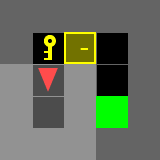

GIF saved: final_minigrid_q_agent.gif
Total reward: 0.9604

Saved:
final_coord_q_table.json
final_rules.json
final_minigrid_q_agent.gif


In [1]:
# ============================================================
# FINAL PIPELINE:
# MiniGrid → Coord State → Navigator Teacher → RuleMiner
# → Coordinate QAgent → Evaluation → GIF
# ============================================================

!pip install minigrid gymnasium matplotlib imageio -q

import gymnasium as gym
import minigrid
import numpy as np
import random
import json
import uuid
import imageio
import matplotlib.pyplot as plt

from dataclasses import dataclass, field, asdict
from typing import Dict, Any, List
from collections import defaultdict, deque
from IPython.display import Image, display


# ============================================================
# ENV
# ============================================================

ENV_NAME = "MiniGrid-DoorKey-5x5-v0"

env = gym.make(
    ENV_NAME,
    render_mode="rgb_array"
)

actions = {
    0: "turn_left",
    1: "turn_right",
    2: "move_forward",
    3: "pickup",
    4: "drop",
    5: "toggle/open",
    6: "done"
}

action_to_id = {v: k for k, v in actions.items()}


# ============================================================
# PREDICATE EXTRACTOR
# ============================================================

class PredicateExtractor:

    def extract(self, env):
        grid = env.grid
        agent_pos = tuple(env.agent_pos)

        predicates = {
            "has_key": env.carrying is not None,
            "key_visible": False,
            "door_visible": False,
            "goal_visible": False,
            "near_key": False,
            "near_door": False,
            "near_goal": False,
            "door_open": False,
            "door_locked": False,
            "path_to_goal_visible": False
        }

        key_positions = []
        door_positions = []
        goal_positions = []

        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)

                if obj is None:
                    continue

                if obj.type == "key":
                    predicates["key_visible"] = True
                    key_positions.append((x, y))

                elif obj.type == "door":
                    predicates["door_visible"] = True
                    door_positions.append((x, y))
                    predicates["door_open"] = obj.is_open
                    predicates["door_locked"] = obj.is_locked

                elif obj.type == "goal":
                    predicates["goal_visible"] = True
                    goal_positions.append((x, y))

        predicates["near_key"] = self._is_near(agent_pos, key_positions)
        predicates["near_door"] = self._is_near(agent_pos, door_positions)
        predicates["near_goal"] = self._is_near(agent_pos, goal_positions)

        if predicates["goal_visible"]:
            if predicates["door_open"] or not predicates["door_visible"]:
                predicates["path_to_goal_visible"] = True

        return predicates

    def _is_near(self, agent_pos, positions, distance_threshold=1):
        ax, ay = agent_pos

        for ox, oy in positions:
            if abs(ax - ox) + abs(ay - oy) <= distance_threshold:
                return True

        return False


# ============================================================
# OBJECT LOCATOR
# ============================================================

class MiniGridObjectLocator:

    def locate(self, env):
        grid = env.grid

        objects = {
            "agent": tuple(map(int, env.agent_pos)),
            "agent_dir": int(env.agent_dir),
            "key": None,
            "door": None,
            "goal": None
        }

        for x in range(grid.width):
            for y in range(grid.height):
                obj = grid.get(x, y)

                if obj is None:
                    continue

                if obj.type == "key":
                    objects["key"] = (x, y)

                elif obj.type == "door":
                    objects["door"] = (x, y)

                elif obj.type == "goal":
                    objects["goal"] = (x, y)

        return objects


# ============================================================
# COORDINATE STATE BUILDER
# ============================================================

class CoordinateStateBuilder:

    def __init__(self):
        self.extractor = PredicateExtractor()
        self.locator = MiniGridObjectLocator()

    def build_state(self, env):
        predicates = self.extractor.extract(env)
        objects = self.locator.locate(env)

        state = dict(predicates)

        ax, ay = objects["agent"]
        state["agent_x"] = ax
        state["agent_y"] = ay
        state["agent_dir"] = objects["agent_dir"]

        for name in ["key", "door", "goal"]:
            pos = objects[name]

            state[f"{name}_x"] = int(pos[0]) if pos is not None else -1
            state[f"{name}_y"] = int(pos[1]) if pos is not None else -1

        return state


class CoordinateStateEncoder:

    def encode(self, state):
        return tuple(
            sorted(
                (k, int(v) if isinstance(v, bool) else v)
                for k, v in state.items()
            )
        )


# ============================================================
# NAVIGATOR TEACHER
# ============================================================

class ObjectNavigator:

    def __init__(self):
        self.locator = MiniGridObjectLocator()

    def choose_target(self, state, objects):
        if not state["has_key"] and objects["key"] is not None:
            return "key", objects["key"]

        if state["has_key"] and not state["door_open"] and objects["door"] is not None:
            return "door", objects["door"]

        if objects["goal"] is not None:
            return "goal", objects["goal"]

        return None, None

    def get_action(self, env, state):
        objects = self.locator.locate(env)

        target_name, target_pos = self.choose_target(state, objects)

        if target_pos is None:
            return env.action_space.sample(), actions[env.action_space.sample()]

        agent_pos = objects["agent"]
        agent_dir = objects["agent_dir"]

        front_pos = self._front_cell(agent_pos, agent_dir)

        if target_name == "key" and front_pos == target_pos:
            return action_to_id["pickup"], "pickup"

        if target_name == "door" and front_pos == target_pos:
            return action_to_id["toggle/open"], "toggle/open"

        if target_name == "goal" and front_pos == target_pos:
            return action_to_id["move_forward"], "move_forward"

        approach_cell = self._find_best_approach_cell(env, target_pos, agent_pos)

        if approach_cell is None:
            return env.action_space.sample(), actions[env.action_space.sample()]

        if agent_pos == approach_cell:
            desired_dir = self._direction_to_cell(agent_pos, target_pos)
            return self._turn_or_move(agent_dir, desired_dir)

        next_cell = self._find_next_cell_towards(env, agent_pos, approach_cell)

        if next_cell is None:
            return env.action_space.sample(), actions[env.action_space.sample()]

        desired_dir = self._direction_to_cell(agent_pos, next_cell)

        return self._turn_or_move(agent_dir, desired_dir)

    def _front_cell(self, pos, direction):
        x, y = pos

        if direction == 0:
            return (x + 1, y)
        if direction == 1:
            return (x, y + 1)
        if direction == 2:
            return (x - 1, y)
        if direction == 3:
            return (x, y - 1)

    def _neighbors(self, pos):
        x, y = pos

        return [
            (x + 1, y),
            (x - 1, y),
            (x, y + 1),
            (x, y - 1)
        ]

    def _find_best_approach_cell(self, env, target, agent_pos):
        candidates = []

        for cell in self._neighbors(target):
            x, y = cell

            if not (0 <= x < env.grid.width and 0 <= y < env.grid.height):
                continue

            obj = env.grid.get(x, y)

            if obj is not None and obj.type != "goal":
                continue

            candidates.append(cell)

        if not candidates:
            return None

        candidates.sort(
            key=lambda c: abs(agent_pos[0] - c[0]) + abs(agent_pos[1] - c[1])
        )

        return candidates[0]

    def _find_next_cell_towards(self, env, start, target):
        queue = deque([start])
        came_from = {start: None}

        while queue:
            current = queue.popleft()

            if current == target:
                break

            for neighbor in self._neighbors(current):
                x, y = neighbor

                if not (0 <= x < env.grid.width and 0 <= y < env.grid.height):
                    continue

                if neighbor in came_from:
                    continue

                obj = env.grid.get(x, y)

                if obj is not None:
                    if obj.type == "wall":
                        continue
                    if obj.type == "door" and not obj.is_open:
                        continue
                    if obj.type == "key":
                        continue

                came_from[neighbor] = current
                queue.append(neighbor)

        if target not in came_from:
            return None

        path = []
        current = target

        while current is not None:
            path.append(current)
            current = came_from[current]

        path.reverse()

        if len(path) < 2:
            return None

        return path[1]

    def _direction_to_cell(self, agent_pos, next_cell):
        ax, ay = agent_pos
        nx, ny = next_cell

        if nx - ax == 1:
            return 0
        if ny - ay == 1:
            return 1
        if nx - ax == -1:
            return 2
        if ny - ay == -1:
            return 3

        return None

    def _turn_or_move(self, agent_dir, desired_dir):
        if agent_dir == desired_dir:
            return action_to_id["move_forward"], "move_forward"

        if (agent_dir - 1) % 4 == desired_dir:
            return action_to_id["turn_left"], "turn_left"

        return action_to_id["turn_right"], "turn_right"


# ============================================================
# EXPERIENCE MEMORY
# ============================================================

@dataclass
class Experience:
    before: Dict[str, Any]
    action: str
    after: Dict[str, Any]
    reward: float
    done: bool = False


class ExperienceMemory:

    def __init__(self):
        self.data = []

    def add(self, before, action, after, reward, done):
        self.data.append(
            Experience(before, action, after, reward, done)
        )

    def get_all(self):
        return self.data

    def __len__(self):
        return len(self.data)


# ============================================================
# REWARD SHAPER
# ============================================================

class RewardShaper:

    def shape(self, before, after, env_reward):
        reward = env_reward - 0.01

        if not before["has_key"] and after["has_key"]:
            reward += 0.3

        if not before["door_open"] and after["door_open"]:
            reward += 0.5

        if not before["near_goal"] and after["near_goal"]:
            reward += 0.2

        if env_reward > 0:
            reward += 1.0

        return reward


# ============================================================
# RULE MINER
# ============================================================

@dataclass
class TransformationRule:
    id: str
    conditions: Dict[str, Any]
    action: str
    effects: Dict[str, Any]
    support: int
    confidence: float
    reward_mean: float


def freeze_dict(d):
    return tuple(sorted(d.items()))


def unfreeze_dict(t):
    return dict(t)


def get_state_diff(before, after):
    diff = {}

    for key in set(before.keys()) | set(after.keys()):
        if before.get(key) != after.get(key):
            diff[key] = after.get(key)

    return diff


class RuleMiner:

    def __init__(self, min_support=3, min_confidence=0.7):
        self.min_support = min_support
        self.min_confidence = min_confidence

    def mine_rules(self, experiences):
        groups = defaultdict(list)

        for exp in experiences:
            for key, value in exp.before.items():
                condition = {key: value}

                groups[
                    (
                        freeze_dict(condition),
                        exp.action
                    )
                ].append(exp)

        rules = []

        for (condition_frozen, action), group in groups.items():
            effect_groups = defaultdict(list)

            for exp in group:
                diff = get_state_diff(exp.before, exp.after)

                if diff:
                    effect_groups[freeze_dict(diff)].append(exp)

            for effect_frozen, effect_group in effect_groups.items():
                support = len(effect_group)
                confidence = support / len(group)

                if support < self.min_support:
                    continue

                if confidence < self.min_confidence:
                    continue

                reward_mean = np.mean([e.reward for e in effect_group])

                rules.append(
                    TransformationRule(
                        id=str(uuid.uuid4()),
                        conditions=unfreeze_dict(condition_frozen),
                        action=action,
                        effects=unfreeze_dict(effect_frozen),
                        support=support,
                        confidence=round(confidence, 3),
                        reward_mean=round(float(reward_mean), 3)
                    )
                )

        return rules


# ============================================================
# Q-LEARNING AGENT
# ============================================================

class QLearningAgent:

    def __init__(
        self,
        action_space,
        alpha=0.2,
        gamma=0.95,
        epsilon=0.05
    ):
        self.action_space = action_space
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = defaultdict(lambda: np.zeros(action_space.n))

    def choose_action(self, state_key):
        if random.random() < self.epsilon:
            action_id = self.action_space.sample()
            return action_id, actions[action_id]

        q_values = self.q_table[state_key]
        action_id = int(np.argmax(q_values))

        return action_id, actions[action_id]

    def update(self, state_key, action_id, reward, next_state_key, done):
        old = self.q_table[state_key][action_id]

        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state_key])

        self.q_table[state_key][action_id] = old + self.alpha * (target - old)

    def save_q_table(self, path):
        data = {
            str(k): v.tolist()
            for k, v in self.q_table.items()
        }

        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=4)


# ============================================================
# BUILD COMPONENTS
# ============================================================

state_builder = CoordinateStateBuilder()
encoder = CoordinateStateEncoder()
navigator = ObjectNavigator()
reward_shaper = RewardShaper()
memory = ExperienceMemory()

q_agent = QLearningAgent(
    action_space=env.action_space,
    alpha=0.2,
    gamma=0.95,
    epsilon=0.02
)


# ============================================================
# TEACHER DEMONSTRATIONS
# ============================================================

TEACHER_EPISODES = 300
MAX_STEPS = 100

teacher_rewards = []
teacher_success = []

for episode in range(TEACHER_EPISODES):
    obs, info = env.reset()

    done = False
    total_reward = 0
    success = False

    before_state = state_builder.build_state(env.unwrapped)

    for step in range(MAX_STEPS):
        action_id, action_name = navigator.get_action(
            env.unwrapped,
            before_state
        )

        obs, env_reward, terminated, truncated, info = env.step(action_id)

        done = terminated or truncated

        after_state = state_builder.build_state(env.unwrapped)

        shaped_reward = reward_shaper.shape(
            before_state,
            after_state,
            env_reward
        )

        memory.add(
            before_state,
            action_name,
            after_state,
            shaped_reward,
            done
        )

        total_reward += env_reward

        if env_reward > 0:
            success = True

        before_state = after_state

        if done:
            break

    teacher_rewards.append(total_reward)
    teacher_success.append(success)

print("Teacher success:", np.mean(teacher_success) * 100)
print("Teacher avg reward:", np.mean(teacher_rewards))
print("Memory size:", len(memory))


# ============================================================
# RULE MINING
# ============================================================

miner = RuleMiner(
    min_support=3,
    min_confidence=0.7
)

rules = miner.mine_rules(memory.get_all())

print("Rules found:", len(rules))

for rule in rules[:10]:
    print("\nIF:", rule.conditions)
    print("ACTION:", rule.action)
    print("THEN:", rule.effects)
    print("support:", rule.support, "confidence:", rule.confidence)


# ============================================================
# Q PRETRAIN ON TEACHER MEMORY
# ============================================================

PRETRAIN_EPOCHS = 30

for epoch in range(PRETRAIN_EPOCHS):
    experiences = memory.get_all()
    random.shuffle(experiences)

    q_change = 0

    for exp in experiences:
        state_key = encoder.encode(exp.before)
        next_state_key = encoder.encode(exp.after)

        action_id = action_to_id[exp.action]

        old_q = q_agent.q_table[state_key][action_id]

        q_agent.update(
            state_key,
            action_id,
            exp.reward,
            next_state_key,
            exp.done
        )

        new_q = q_agent.q_table[state_key][action_id]
        q_change += abs(new_q - old_q)

    print(f"Epoch {epoch + 1:02d} | q_change={q_change:.4f}")


# ============================================================
# EVALUATION
# ============================================================

TEST_EPISODES = 100

test_rewards = []
test_success = []

q_agent.epsilon = 0.02

for episode in range(TEST_EPISODES):
    obs, info = env.reset()

    done = False
    total_reward = 0
    success = False

    state = state_builder.build_state(env.unwrapped)

    for step in range(MAX_STEPS):
        state_key = encoder.encode(state)

        action_id, action_name = q_agent.choose_action(state_key)

        obs, env_reward, terminated, truncated, info = env.step(action_id)

        done = terminated or truncated

        total_reward += env_reward

        if env_reward > 0:
            success = True

        state = state_builder.build_state(env.unwrapped)

        if done:
            break

    test_rewards.append(total_reward)
    test_success.append(success)

print("\n========== FINAL TEST ==========")
print("Success rate:", np.mean(test_success) * 100)
print("Avg reward:", np.mean(test_rewards))


# ============================================================
# GIF RENDER
# ============================================================

frames = []

obs, info = env.reset()
done = False

state = state_builder.build_state(env.unwrapped)
total_reward = 0

for step in range(MAX_STEPS):
    frames.append(env.render())

    state_key = encoder.encode(state)

    action_id, action_name = q_agent.choose_action(state_key)

    obs, reward, terminated, truncated, info = env.step(action_id)

    done = terminated or truncated
    total_reward += reward

    print(
        f"step={step:03d} | "
        f"action={action_name:12s} | "
        f"reward={reward:.3f} | "
        f"total={total_reward:.3f}"
    )

    state = state_builder.build_state(env.unwrapped)

    if done:
        frames.append(env.render())
        break

gif_path = "final_minigrid_q_agent.gif"

imageio.mimsave(
    gif_path,
    frames,
    fps=5
)

display(Image(filename=gif_path))

print("GIF saved:", gif_path)
print("Total reward:", total_reward)


# ============================================================
# SAVE
# ============================================================

q_agent.save_q_table("final_coord_q_table.json")

with open("final_rules.json", "w", encoding="utf-8") as f:
    json.dump(
        [asdict(rule) for rule in rules],
        f,
        ensure_ascii=False,
        indent=4
    )

print("\nSaved:")
print("final_coord_q_table.json")
print("final_rules.json")
print("final_minigrid_q_agent.gif")

In [2]:

# ============================================================
# ЧАСТЬ 21: PREDICATE GENERATOR
# автоматически создаёт новые derived predicates из координат
# ============================================================

class PredicateGenerator:

    def __init__(self):
        pass

    def generate(self, state):
        new_predicates = {}

        ax = state["agent_x"]
        ay = state["agent_y"]

        # ----------------------------------------------------
        # расстояния до объектов
        # ----------------------------------------------------

        objects = ["key", "door", "goal"]

        for obj in objects:
            ox = state.get(f"{obj}_x", -1)
            oy = state.get(f"{obj}_y", -1)

            if ox == -1 or oy == -1:
                new_predicates[f"distance_to_{obj}"] = -1
                new_predicates[f"{obj}_close"] = False
                new_predicates[f"{obj}_very_close"] = False
                new_predicates[f"{obj}_same_row"] = False
                new_predicates[f"{obj}_same_col"] = False
                continue

            distance = abs(ax - ox) + abs(ay - oy)

            new_predicates[f"distance_to_{obj}"] = distance
            new_predicates[f"{obj}_close"] = distance <= 2
            new_predicates[f"{obj}_very_close"] = distance <= 1
            new_predicates[f"{obj}_same_row"] = ay == oy
            new_predicates[f"{obj}_same_col"] = ax == ox

        # ----------------------------------------------------
        # направление относительно агента
        # ----------------------------------------------------

        for obj in objects:
            ox = state.get(f"{obj}_x", -1)
            oy = state.get(f"{obj}_y", -1)

            if ox == -1 or oy == -1:
                continue

            new_predicates[f"{obj}_is_left"] = ox < ax
            new_predicates[f"{obj}_is_right"] = ox > ax
            new_predicates[f"{obj}_is_up"] = oy < ay
            new_predicates[f"{obj}_is_down"] = oy > ay

        # ----------------------------------------------------
        # объект прямо перед агентом
        # ----------------------------------------------------

        front_x, front_y = self._front_cell(
            ax,
            ay,
            state["agent_dir"]
        )

        for obj in objects:
            ox = state.get(f"{obj}_x", -1)
            oy = state.get(f"{obj}_y", -1)

            new_predicates[f"{obj}_in_front"] = (
                ox == front_x and oy == front_y
            )

        # ----------------------------------------------------
        # полезные стратегические признаки
        # ----------------------------------------------------

        new_predicates["can_pickup_key"] = (
            not state.get("has_key", False)
            and new_predicates.get("key_in_front", False)
        )

        new_predicates["can_open_door"] = (
            state.get("has_key", False)
            and not state.get("door_open", False)
            and new_predicates.get("door_in_front", False)
        )

        new_predicates["can_finish"] = (
            state.get("door_open", False)
            and new_predicates.get("goal_in_front", False)
        )

        return new_predicates

    def extend_state(self, state):
        generated = self.generate(state)

        extended_state = dict(state)
        extended_state.update(generated)

        return extended_state

    def _front_cell(self, x, y, direction):
        # MiniGrid:
        # 0 = right
        # 1 = down
        # 2 = left
        # 3 = up

        if direction == 0:
            return x + 1, y
        if direction == 1:
            return x, y + 1
        if direction == 2:
            return x - 1, y
        if direction == 3:
            return x, y - 1

        return x, y


# ============================================================
# EXTENDED STATE BUILDER
# ============================================================

class ExtendedStateBuilder:

    def __init__(self, base_state_builder):
        self.base_state_builder = base_state_builder
        self.predicate_generator = PredicateGenerator()

    def build_state(self, env):
        base_state = self.base_state_builder.build_state(env)

        extended_state = self.predicate_generator.extend_state(
            base_state
        )

        return extended_state


# ============================================================
# ТЕСТ PREDICATE GENERATOR
# ============================================================

extended_state_builder = ExtendedStateBuilder(
    state_builder
)

obs, info = env.reset()

extended_state = extended_state_builder.build_state(
    env.unwrapped
)

print("========== EXTENDED STATE ==========")

for k, v in extended_state.items():
    print(f"{k:25s}: {v}")


# ============================================================
# НОВЫЙ ENCODER МОЖЕТ БЫТЬ ТОТ ЖЕ
# ============================================================

extended_encoder = CoordinateStateEncoder()


# ============================================================
# СОБИРАЕМ TEACHER MEMORY С НОВЫМИ PREDICATES
# ============================================================

EXT_TEACHER_EPISODES = 300
MAX_STEPS = 100

extended_memory = ExperienceMemory()

extended_teacher_rewards = []
extended_teacher_success = []

for episode in range(EXT_TEACHER_EPISODES):

    obs, info = env.reset()

    done = False
    total_reward = 0
    success = False

    before_state = extended_state_builder.build_state(
        env.unwrapped
    )

    for step in range(MAX_STEPS):

        # Navigator может использовать extended state,
        # потому что старые ключи в нём тоже есть
        action_id, action_name = navigator.get_action(
            env.unwrapped,
            before_state
        )

        obs, env_reward, terminated, truncated, info = env.step(
            action_id
        )

        done = terminated or truncated

        after_state = extended_state_builder.build_state(
            env.unwrapped
        )

        shaped_reward = reward_shaper.shape(
            before_state,
            after_state,
            env_reward
        )

        extended_memory.add(
            before_state,
            action_name,
            after_state,
            shaped_reward,
            done
        )

        total_reward += env_reward

        if env_reward > 0:
            success = True

        before_state = after_state

        if done:
            break

    extended_teacher_rewards.append(total_reward)
    extended_teacher_success.append(success)

print("\nExtended teacher success:", np.mean(extended_teacher_success) * 100)
print("Extended teacher avg reward:", np.mean(extended_teacher_rewards))
print("Extended memory size:", len(extended_memory))


# ============================================================
# RULE MINING НА РАСШИРЕННЫХ PREDICATES
# ============================================================

extended_rules = miner.mine_rules(
    extended_memory.get_all()
)

print("\nExtended rules found:", len(extended_rules))

for rule in extended_rules[:20]:
    print("\nIF:", rule.conditions)
    print("ACTION:", rule.action)
    print("THEN:", rule.effects)
    print("support:", rule.support)
    print("confidence:", rule.confidence)
    print("reward_mean:", rule.reward_mean)


# ============================================================
# ОБУЧАЕМ EXTENDED Q-AGENT
# ============================================================

extended_q_agent = QLearningAgent(
    action_space=env.action_space,
    alpha=0.2,
    gamma=0.95,
    epsilon=0.02
)

EXT_PRETRAIN_EPOCHS = 30

for epoch in range(EXT_PRETRAIN_EPOCHS):

    experiences = extended_memory.get_all()
    random.shuffle(experiences)

    q_change = 0

    for exp in experiences:

        state_key = extended_encoder.encode(exp.before)
        next_state_key = extended_encoder.encode(exp.after)

        action_id = action_to_id[exp.action]

        old_q = extended_q_agent.q_table[state_key][action_id]

        extended_q_agent.update(
            state_key,
            action_id,
            exp.reward,
            next_state_key,
            exp.done
        )

        new_q = extended_q_agent.q_table[state_key][action_id]
        q_change += abs(new_q - old_q)

    print(
        f"Extended epoch {epoch + 1:02d} | "
        f"q_change={q_change:.4f}"
    )


# ============================================================
# ТЕСТ EXTENDED Q-AGENT
# ============================================================

EXT_TEST_EPISODES = 100

extended_test_rewards = []
extended_test_success = []

extended_q_agent.epsilon = 0.02

for episode in range(EXT_TEST_EPISODES):

    obs, info = env.reset()

    done = False
    total_reward = 0
    success = False

    state = extended_state_builder.build_state(
        env.unwrapped
    )

    for step in range(MAX_STEPS):

        state_key = extended_encoder.encode(state)

        action_id, action_name = extended_q_agent.choose_action(
            state_key
        )

        obs, env_reward, terminated, truncated, info = env.step(
            action_id
        )

        done = terminated or truncated

        total_reward += env_reward

        if env_reward > 0:
            success = True

        state = extended_state_builder.build_state(
            env.unwrapped
        )

        if done:
            break

    extended_test_rewards.append(total_reward)
    extended_test_success.append(success)

print("\n========== EXTENDED Q-AGENT TEST ==========")
print("Success rate:", np.mean(extended_test_success) * 100)
print("Avg reward:", np.mean(extended_test_rewards))


# ============================================================
# СОХРАНЕНИЕ
# ============================================================

extended_q_agent.save_q_table(
    "extended_q_table.json"
)

with open("extended_rules.json", "w", encoding="utf-8") as f:
    json.dump(
        [asdict(rule) for rule in extended_rules],
        f,
        ensure_ascii=False,
        indent=4
    )

print("\nSaved:")
print("extended_q_table.json")
print("extended_rules.json")

========== EXTENDED STATE ==========
has_key                  : False
key_visible              : True
door_visible             : True
goal_visible             : True
near_key                 : True
near_door                : False
near_goal                : False
door_open                : False
door_locked              : True
path_to_goal_visible     : False
agent_x                  : 1
agent_y                  : 2
agent_dir                : 1
key_x                    : 1
key_y                    : 3
door_x                   : 2
door_y                   : 1
goal_x                   : 3
goal_y                   : 3
distance_to_key          : 1
key_close                : True
key_very_close           : True
key_same_row             : False
key_same_col             : True
distance_to_door         : 2
door_close               : True
door_very_close          : False
door_same_row            : False
door_same_col            : False
distance_to_goal         : 3
goal_close               : Fal